In [20]:
import sys
import os
sys.path.append(os.path.abspath("../"))  # or "../../" depending on location

In [21]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader
from utils.formate_matrix_toMLData import *
from models.model_0929 import *
import matplotlib.pyplot as plt
import japanize_matplotlib
plt.rcParams["font.size"] = 22
np.set_printoptions(suppress=True)
import seaborn as sns

In [22]:
formater = formate_dataMatrix()

# 読み込む対象の拡張子（例: .csv のみに限定）
VALID_EXTENSIONS = (".csv", ".txt")
IGNORED_PREFIXES = ("._", ".DS_Store", "Thumbs.db")

# ファイルを処理する関数
def process_file(file_path, states_sets, delt_sets, true_sets,targets_sets,ll_use):
    try:
        print("Processing:", file_path)
        with open(file_path, 'rb') as f:
            all_matrix = np.loadtxt(f, delimiter=",")

        tm = matrix_trimer(all_matrix)
        true_trm = tm.trim_transitionRateMatrix(start = 0, end = 4)
        true_vec = np.array(formater.GetOutputVector_byDiagonal(true_trm))
        data = []
        if ll_use:
            
            ll_trm = tm.trim_transitionRateMatrix(start = 4, end = 8)
            ll_vec = np.array(formater.GetOutputVector_byDiagonal(ll_trm))
            for v in ll_vec:
                if v < 1e-2 or v>1:
                    return
            data = tm.trim_data(start = 8)
        else:
            data = tm.trim_data(start = 4)
            ll_vec = np.array([0,0,0])
            
        print(data)
        # state: shape (2, num_samples_i)
        state = np.stack([data[:, 0], data[:, 1]], axis=0)
        states_sets.append(state)
        delt_sets.append(data[:, 2])
        true_sets.append(true_vec)
        targets_sets.append(ll_vec)

    except Exception as e:
        print(f"❌ Skipping file: {file_path} (Reason: {e})")

# ディレクトリ内のファイルを一括処理
def process_all_files_in_directory(directory, func, states_sets, delt_sets, true_sets,targets_sets,ll_use = True):
    for filename in os.listdir(directory):
        if filename.startswith(IGNORED_PREFIXES):
            continue
        if not filename.endswith(VALID_EXTENSIONS):
            continue

        file_path = os.path.join(directory, filename)
        if os.path.isfile(file_path):
            func(file_path,states_sets, delt_sets, true_sets,targets_sets,ll_use)

# 実行
# process_all_files_in_directory(data_dir,process_file, test_states, test_del_t, test_targets)



# # データセットとデータローダーの作成
# test_dataset = varSets_Datasets(test_states, test_del_t, test_targets)
# use_cuda = torch.cuda.is_available()
# test_dataloader = DataLoader(
#     test_dataset,
#     batch_size=1,
#     shuffle=False,
#     collate_fn=collate_fn,
#     pin_memory=use_cuda,
# )
# data_iter = iter(test_dataloader)

## モデル読み込み

In [23]:
if torch.cuda.is_available():
    device = torch.device("cuda")
# elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
#     device = torch.device("mps")
else:
    device = torch.device("cpu")

model = DeepSets_varSets_forDiagnel(device=device)
model.load_state_dict(torch.load("../model_weights/mixed_distribution/model_0223.pt", map_location=device))
model.eval()

class all_lifespan_loss(nn.Module):
    def forward(self, outputs, targets):
        
        y_pred_inverse = 1.0 / (outputs)
        y_true_inverse = 1.0 / (targets)

        # 逆数の差の絶対値
        loss_tensor = torch.abs(y_pred_inverse - y_true_inverse)[0]
        return loss_tensor, y_true_inverse[0], y_pred_inverse

criterion = all_lifespan_loss()

/tmp/ipykernel_688902/2603439067.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("../model_weights/mixed_distribution/model_0223.pt", ma

## モデルの検証

In [15]:
test_states = []
test_del_t = []
test_targets = []
dummy = []
base_dir = "/mnt/ssd/datas/"
# data_dir = "/media/user/TRANSCEND/datas/discrete_test_rundomN"
data_dir = "discrete_test_N5000_ll"

# 実行
process_all_files_in_directory(base_dir+data_dir,process_file, test_states, test_del_t,test_targets,dummy,True)


Processing: /mnt/ssd/datas/discrete_test_N5000_ll/22_5000_4.csv
[[1.  1.  4.4]
 [1.  1.  2.9]
 [1.  1.  4.8]
 ...
 [3.  3.  4.8]
 [1.  1.  4.4]
 [1.  1.  4.4]]
Processing: /mnt/ssd/datas/discrete_test_N5000_ll/52_5000_4.csv
[[ 1.   1.  67.7]
 [ 1.   3.  67.3]
 [ 1.   1.  67.3]
 ...
 [ 1.   2.  76.5]
 [ 3.   4.  76.5]
 [ 3.   3.  87.5]]
Processing: /mnt/ssd/datas/discrete_test_N5000_ll/59_5000_4.csv
[[ 3.   3.  80.8]
 [ 1.   4.  80.8]
 [ 3.   3.  77.6]
 ...
 [ 3.   4.  80.8]
 [ 1.   2.   6.9]
 [ 3.   4.  88.8]]
Processing: /mnt/ssd/datas/discrete_test_N5000_ll/33_5000_4.csv
[[ 3.   4.  97.7]
 [ 3.   3.  97.7]
 [ 3.   3.  97.7]
 ...
 [ 3.   3.  97.7]
 [ 3.   4.  97.7]
 [ 3.   3.  49.7]]
Processing: /mnt/ssd/datas/discrete_test_N5000_ll/54_5000_4.csv
[[ 3.   4.  29.7]
 [ 1.   3.  97.4]
 [ 1.   2.  97.4]
 ...
 [ 2.   4.  97.4]
 [ 1.   2.  30.7]
 [ 2.   4.  97.4]]
Processing: /mnt/ssd/datas/discrete_test_N5000_ll/28_5000_4.csv
Processing: /mnt/ssd/datas/discrete_test_N5000_ll/61_5000_4.csv


In [16]:
rows = []
for i in range(len(test_states)):
    for j in range(3):
        row = []
        row.append(i)
        row.append(len(test_states[i][0]))
        row.append(j+1)
        row.append(dummy[i][j])
        row.append(test_targets[i][j])
        rows.append(row)

df = pd.DataFrame(rows, columns=['data_id', 'k', 'state', 'MLE', 'true'])
df.to_csv('out/MLE_vs_TRUE_N500-5000.csv', index=False)

In [17]:
k_list = []
for i in range(len(test_states)):
    k_list.append(len(test_states[i][0]))
print(k_list)

[5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 500

In [18]:
# MLE__loss_list = []
# k_list = []
# for i in range(len(test_states)):
#     loss= []
#     for j in range(3):
#         eps = 1e-8
        
#         l = np.abs(1/(dummy[i][j] + eps) - 1/(test_targets[i][j] + eps))
#         loss.append(l)
#     MLE__loss_list.append(loss)
#     k_list.append(len(test_states[i][0]))

# plt.figure(figsize=(10, 6))
# sns.scatterplot(x=k_list, y=[loss[0] for loss in MLE__loss_list], label='state 1', alpha=0.7, color='blue')
# sns.scatterplot(x=k_list, y=[loss[1] for loss in MLE__loss_list], label='state 2', alpha=0.7, color='orange')
# sns.scatterplot(x=k_list, y=[loss[2] for loss in MLE__loss_list], label='state 3', alpha=0.7, color='green')
# plt.ylim(1e-3,100)
# plt.xlabel('サンプル数 N')
# plt.ylabel('平均絶対誤差 (MAE)')
# plt.title('MLEとTrue valueの平均絶対誤差比較')

# # sns.histplot([loss[0] for loss in MLE__loss_list], label='state 1', color='blue', kde=True, stat="density", bins=1000, alpha=0.5)
# # sns.histplot([loss[1] for loss in MLE__loss_list], label='state 2', color='orange', kde=True, stat="density", bins=1000, alpha=0.5)
# # sns.histplot([loss[2] for loss in MLE__loss_list], label='state 3', color='green', kde=True, stat="density", bins=1000, alpha=0.5)
# # plt.xlabel('平均絶対誤差 (MAE)')
# # plt.xlim(1e-3,100)
# # plt.yscale('log')

# plt.legend() 
    

In [19]:
# MLE__loss_list = []

# for i in range(len(test_states)):
#     loss= []
#     for j in range(3):
#         eps = 1e-8
#         if 1/dummy[i][j] < 1e-6 or 1/dummy[i][j] > 1e4:
#             continue
#         l = 1/(dummy[i][j] + eps) - 1/(test_targets[i][j] + eps)
#         loss.append(l)
#     MLE__loss_list.append(loss)

# loss1 = [lst[0] for lst in MLE__loss_list if len(lst) > 0]
# loss2 = [lst[1] for lst in MLE__loss_list if len(lst) > 1]
# loss3 = [lst[2] for lst in MLE__loss_list if len(lst) > 2]


# plt.figure()
# plt.hist(loss1, bins=500, alpha=0.5, label="state 1")
# plt.hist(loss2, bins=500, alpha=0.5, label="state 2")
# plt.hist(loss3, bins=500, alpha=0.5, label="state 3")
# plt.legend()
# plt.xlabel("loss"); plt.ylabel("count")
# plt.tight_layout()
# plt.show()

2451



,index,paramerter,mle,pred,loss,n
0,0,1,50.475849,50.269142,0.206707,5000
1,0,2,94.070244,90.563698,3.506546,5000
2,0,3,40.280636,39.705280,0.575356,5000
3,1,1,68.046509,68.109756,0.063248,5000
4,1,2,67.810165,67.555420,0.254745,5000
...,...,...,...,...,...,...
2446,815,2,1.360714,2.205173,0.844458,5000
2447,815,3,84.644669,84.860710,0.216042,5000
2448,816,1,95.484993,95.802750,0.317757,5000
2449,816,2,1.265308,2.291699,1.026391,5000


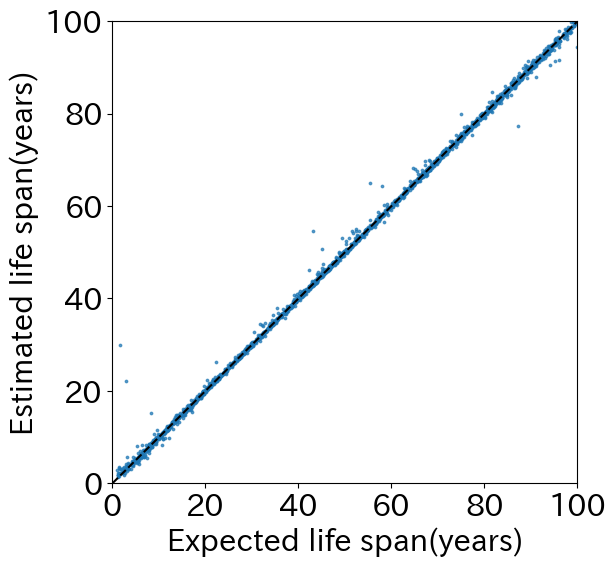

In [24]:
# データセットとデータローダーの作成
test_dataset = varSets_Datasets(test_states, test_del_t, dummy)
use_cuda = torch.cuda.is_available()
test_dataloader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    collate_fn=collate_fn,
    pin_memory=use_cuda,
)
data_iter = iter(test_dataloader)
d_idxes = []
param_id =[]
loss_list = []
outs_lifespan = []
true_lifespan = []
d_lengths = []

for idx,(states, delta_t, targets, lengths) in enumerate(data_iter):
    with torch.no_grad():
        states = states.to(device, non_blocking=True).long()
        delta_t = delta_t.to(device, non_blocking=True).float()
        targets = targets.to(device, non_blocking=True).float()
        lengths = lengths.to(device, non_blocking=True).long()

        outputs = model(states, delta_t, lengths)[0]
        loss_tensor, true_expect, pred_expect = criterion(outputs, targets)

        true_expect_cpu = true_expect.detach().cpu()
        pred_expect_cpu = pred_expect.detach().cpu()
        batch_loss = torch.abs(true_expect_cpu - pred_expect_cpu)

        true_lifespan.extend(true_expect_cpu.tolist())
        outs_lifespan.extend(pred_expect_cpu.tolist())
        loss_list.extend(batch_loss.tolist())
        for i in range(3):
            param_id.append(i+1)
            d_idxes.append(idx)
            d_lengths.extend(lengths.tolist())

print(len(outs_lifespan))
print()    
        
df = pd.DataFrame({
        "index": d_idxes,
        "paramerter": param_id,
        "mle": true_lifespan,
        "pred": outs_lifespan,
        "loss": loss_list,
        "n":d_lengths
    })
display(df)
df.to_csv("out_0223/result_N5000_mle.csv", index=False, encoding="utf-8")


plt.figure(figsize=(6,6))
x = np.linspace(0, 100, 1000)
plt.xlim(0,100)
plt.ylim(0,100)
plt.xlabel("Expected life span(years)")
plt.ylabel("Estimated life span(years)")
plt.plot(x,x,color="#000000", linestyle = '--',zorder= 5)

plt.scatter(df["mle"],df["pred"],s = 3,alpha=0.7)
# plt.scatter(df["true"],df["pred"],color = "#d69c6a",edgecolors="#d79e6b",s = 20,  zorder= 1)
plt.show()

In [11]:
# plt.figure(figsize=(6,6))
# x = np.linspace(0, 100, 1000)
# plt.xlim(0,100)
# plt.ylim(0,50)
# plt.xlabel("Life Span Loss(years)")
# plt.ylabel("Estimated life span(years)")
# # plt.plot(x,x,color="#000000", linestyle = '--',zorder= 5)
# a,b,c=np.polyfit(df["true"],df["loss"],2)
# plt.plot(x,a*x*x+b*x+c,color="#ff0000", linestyle = '-',zorder= 5,label=f"y={a:.2f}x+{b:.2f}")
# eq_text = f"y = {a:.5f}x^2 + {b:.5f}x+{c:.5f}"
# plt.text(0.05, 0.95, eq_text, transform=plt.gca().transAxes,
#          fontsize=12, verticalalignment='top')
# plt.scatter(df["true"],df["loss"],s = 3,alpha=0.7)
# # plt.scatter(df["true"],df["pred"],color = "#d69c6a",edgecolors="#d79e6b",s = 20,  zorder= 1)
# plt.show()

In [12]:
# plt.figure(figsize=(6,6))
# x = np.linspace(500,5000)
# # plt.xlim(0,100)
# # plt.ylim(0,100)
# a,b=np.polyfit(df["n"],df["loss"],1)
# plt.xlabel("")
# plt.ylabel("Estimated life span(years)")
# # plt.plot(x,x,color="#000000", linestyle = '--',zorder= 5)
# plt.plot(x,a*x+b,color="#ff0000", linestyle = '-',zorder= 5,label=f"y={a:.6f}x+{b:.2f}")
# eq_text = f"y = {a:.6f}x + {b:.6f}"
# plt.text(0.05, 0.95, eq_text, transform=plt.gca().transAxes,
#          fontsize=12, verticalalignment='top')
# plt.scatter(df["n"],df["loss"],s = 3,alpha=0.7)
# # plt.scatter(df["true"],df["pred"],color = "#d69c6a",edgecolors="#d79e6b",s = 20,  zorder= 1)
# plt.show()

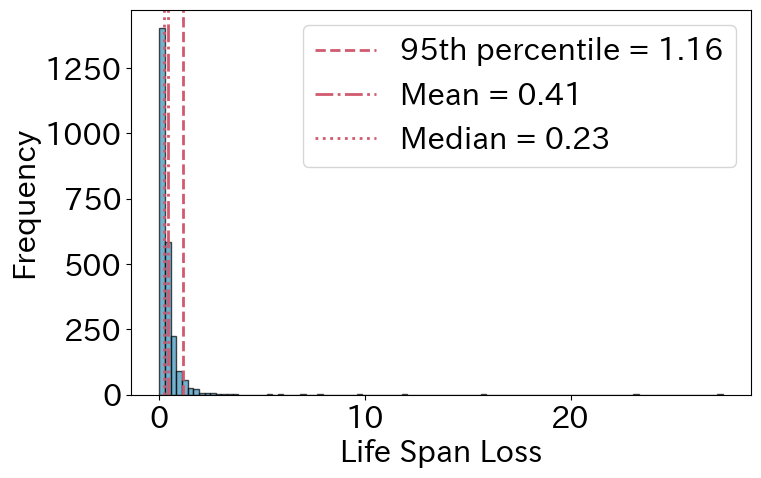

In [13]:
colors = ['#3A8FB7', '#90B44B', '#EFBB24', '#D05A6E']
p95 = np.percentile(df["loss"], 95)
mean = np.mean(df["loss"])
median = np.median(df["loss"])
plt.figure(figsize=(8, 5))
plt.hist(df["loss"], bins=100, edgecolor="black", alpha=0.7,color = colors[0])
plt.axvline(p95, color=colors[3], linestyle="--", linewidth=2, label=f"95th percentile = {p95:.2f}")
plt.axvline(mean, color=colors[3], linestyle="-.", linewidth=2, label=f"Mean = {mean:.2f}")
plt.axvline(median, color=colors[3], linestyle=":", linewidth=2, label=f"Median = {median:.2f}")
plt.xlabel("Life Span Loss")
plt.ylabel("Frequency")
# plt.title("Histogram of Loss with 95th Percentile")
plt.legend()
plt.savefig("out_0223/loss_histogram_N-500-5000.png", dpi=300,bbox_inches="tight")
plt.show()

## データセットのサイズ別の推論結果

In [14]:
# #データセットごとの読み込み
# dataset_list = [200,400,600,800,1000]
# states_sets = []
# del_t_sets = []
# true_sets = []
# targets_sets = []
# for dataset_size in dataset_list:
#     data_dir = f"{base_dir}/testdata_n{str(dataset_size)}"
#     states = []
#     del_ts = []
#     trues = []
#     targets = []
#     process_all_files_in_directory(data_dir,process_file, states, del_ts, trues,targets)
#     states_sets.append(states)
#     del_t_sets.append(del_ts)
#     true_sets.append(trues)
#     targets_sets.append(targets)

In [15]:
# #データセットごとの推論
# loss_lists = []
# outs_lifespan_sets = []
# ll_lifespan_sets = []
# true_lifespan_sets = []

# for i in range(len(dataset_list)):
#     true_lifespan = []
#     for j in range(len(true_sets[i])):
        
#         for k in range(3):
#             true_lifespan.append(1/true_sets[i][j][k])
        
#     true_lifespan_sets.append(true_lifespan)

# for i in range(len(dataset_list)):
#     states = states_sets[i]
#     del_ts = del_t_sets[i]
#     targets = targets_sets[i]

#     test_dataset = varSets_Datasets(states, del_ts, targets)
#     use_cuda = torch.cuda.is_available()
#     test_dataloader = DataLoader(
#         test_dataset,
#         batch_size=1,
#         shuffle=False,
#         collate_fn=collate_fn,
#         pin_memory=use_cuda,
#     )
#     data_iter = iter(test_dataloader)
#     print(len(data_iter))
#     loss_list = []
#     outs_lifespan = []
#     ll_lifespan = []

#     for states, delta_t, targets, lengths in data_iter:
#         with torch.no_grad():
#             states = states.to(device, non_blocking=True).long()
#             delta_t = delta_t.to(device, non_blocking=True).float()
#             targets = targets.to(device, non_blocking=True).float()
#             lengths = lengths.to(device, non_blocking=True).long()

#             outputs = model(states, delta_t, lengths)[0]
#             loss_tensor, true_expect, pred_expect = criterion(outputs, targets)
#             # print("===")
#             # print("---")
#             # print(loss_tensor,true_expect, pred_expect)
#             ll_expect_cpu = true_expect.detach().cpu()
#             pred_expect_cpu = pred_expect.detach().cpu()
#             batch_loss = torch.abs(ll_expect_cpu - pred_expect_cpu)
#             # print("---")
#             # print(ll_expect_cpu,pred_expect_cpu,batch_loss)
#             ll_lifespan.extend(ll_expect_cpu.tolist())
#             outs_lifespan.extend(pred_expect_cpu.tolist())
#             loss_list.extend(batch_loss.tolist())

#     loss_lists.append(loss_list)
#     outs_lifespan_sets.append(outs_lifespan)
#     ll_lifespan_sets.append(ll_lifespan)

In [16]:
# plt.figure(figsize=(6,6))
# x = np.linspace(0, 100, 1000)
# color_list = ["#d69c6a", "#acf087", "#8fc8bb", "#6a7ed6", "#493bc4"]
# plt.xlim(1,100)
# plt.ylim(1,100)
# plt.xlabel("期待寿命の真値（年）")
# plt.ylabel("推定期待寿命(年)")
# plt.plot(x,x,color="#000000", linestyle = '--',zorder= 0)
# for i in range(len(dataset_list)):
#     df = pd.DataFrame({
#         "ll": ll_lifespan_sets[i],
#         "pred": outs_lifespan_sets[i],
#         "loss": loss_lists[i],
#     })
#     plt.scatter(df["ll"],df["pred"],color = color_list[i],edgecolors=color_list[i],s = 3,  alpha=0.2*(5-i))

# plt.show()


In [17]:
# gap_ll = []
# gap_eval = []
# for i in range(len(dataset_list)):
#     l = []
#     e = []
#     for j in range(len(true_lifespan_sets[i])):
        
#         e.append(abs(true_lifespan_sets[i][j]-outs_lifespan_sets[i][j]))
#         l.append(abs(true_lifespan_sets[i][j]-ll_lifespan_sets[i][j]))
        
#     gap_ll.append(l)
#     gap_eval.append(e)
            

# filtered_gap_ll = []
# filtered_gap_eval = []
# for i in range(len(dataset_list)):
#     temp_ll = np.array(gap_ll[i])
#     temp_eval = np.array(gap_eval[i])
#     lower = np.percentile(temp_ll, 0)
#     upper = np.percentile(temp_ll, 99)
#     mask = (temp_ll >= lower) & (temp_ll <= upper)
#     filtered_ll = temp_ll
#     filterd_eval = temp_eval
#     # filterd_eval = temp_eval
#     filtered_gap_ll.append(filtered_ll)
#     filtered_gap_eval.append(filterd_eval)    

In [18]:
# # ---- Violinプロット用にデータを整形 ----
# plot_data = []
# for label, ll_vals, ev_vals in zip(dataset_list, filtered_gap_ll, filtered_gap_eval):
#     print(label,len(ll_vals),len(ev_vals))
#     for v in ll_vals:
#         plot_data.append({"Dataset": label, "Value": v, "Type": "gap_ll"})
        
#     for v in ev_vals:
#         plot_data.append({"Dataset": label, "Value": v, "Type": "gap_eval"})
    
    

# df = pd.DataFrame(plot_data)

# # ---- Violin plot 横並び ----
# plt.figure(figsize=(12, 6))
# # sns.violinplot(data=df, x="Dataset", y="Value", hue="Type", split=True)
# sns.boxplot(data=df, x="Dataset", y="Value", hue="Type")
# plt.ylim((-1,50))
# plt.title("gap_ll vs gap_eval ")
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()

# 

In [19]:
# M = np.loadtxt("../test_base_10000_4.csv",delimiter=",")
# trm = matrix_trimer(M).trim_transitionRateMatrix()
# true_vec = formate_dataMatrix().GetOutputVector_byDiagonal(trm)
# true_vec = torch.from_numpy(true_vec)
# true_lifespan = 1/true_vec
# dataset_list = [200,400,600,800,1000]
# states_sets = []
# del_t_sets = []
# targets_sets = []
# dummys = []
# for dataset_size in dataset_list:
#     data_dir = f"{base_dir}/test_from_base{str(dataset_size)}"
#     states = []
#     del_ts = []
#     targets = []
#     dummy = []
#     process_all_files_in_directory(data_dir,process_file, states, del_ts, targets,dummy,False)
#     states_sets.append(states)
#     del_t_sets.append(del_ts)
#     targets_sets.append(targets)
#     dummys.append(dummy)


In [20]:
# #データセットごとの推論
# loss_lists = []
# outs_lifespan_sets = []
# ll_lifespan_sets = []



# for i in range(len(dataset_list)):
#     states = states_sets[i]
#     del_ts = del_t_sets[i]
#     targets = targets_sets[i]
    
#     test_dataset = varSets_Datasets(states, del_ts, targets)
#     use_cuda = torch.cuda.is_available()
#     test_dataloader = DataLoader(
#         test_dataset,
#         batch_size=1,
#         shuffle=False,
#         collate_fn=collate_fn,
#         pin_memory=use_cuda,
#     )
#     data_iter = iter(test_dataloader)
    
#     outs_lifespan = []
#     ll_lifespan = []

#     for states, delta_t, targets, lengths in data_iter:
#         with torch.no_grad():
#             states = states.to(device, non_blocking=True).long()
#             delta_t = delta_t.to(device, non_blocking=True).float()
#             targets = targets.to(device, non_blocking=True).float()
#             lengths = lengths.to(device, non_blocking=True).long()

#             outputs = model(states, delta_t, lengths)[0]
#             loss_tensor, true_expect, pred_expect = criterion(outputs, targets)
            
#             ll_expect_cpu = true_expect.detach().cpu()
#             pred_expect_cpu = pred_expect.detach().cpu()
#             batch_loss = torch.abs(ll_expect_cpu - pred_expect_cpu)
            
#             ll_lifespan.append(ll_expect_cpu)
#             outs_lifespan.append(pred_expect_cpu)
            

#     # loss_lists.append(loss_list)
#     outs_lifespan_sets.append(outs_lifespan)
#     ll_lifespan_sets.append(ll_lifespan)

In [21]:
# outs_lifespan_sets

In [22]:
# plt.figure(figsize=(6,6))
# x = np.linspace(0, 100, 1000)
# color_list = ["#d69c6a", "#acf087", "#8fc8bb", "#6a7ed6", "#493bc4"]
# plt.xlim(0,100)
# plt.ylim(0,100)
# plt.xlabel("期待寿命の真値（年）")
# plt.ylabel("推定期待寿命(年)")
# plt.plot(x,x,color="#000000", linestyle = '--',zorder= 0)
# for i in range(len(dataset_list)):
#     df = pd.DataFrame({
#         "ll": ll_lifespan_sets[i],
#         "pred": outs_lifespan_sets[i],
#         # "loss": loss_lists[i],
#     })
#     plt.scatter(df["ll"],df["pred"],color = color_list[i],edgecolors=color_list[i],s = 20,  alpha=0.2*(5-i))

# plt.show()


1データセットからのサンプリング

In [23]:
# gap_ll = []
# gap_eval = []
# for i in range(len(dataset_list)):
    
#     l = []
#     e = []
#     for j in range(len(ll_lifespan_sets[i])):
#         l_per_case = []
#         e_per_case = []
#         for k in range(3):
        
#             e_per_case.append(abs(true_lifespan[k] -outs_lifespan_sets[i][j][k]))
#             l_per_case.append(abs(true_lifespan[k]-ll_lifespan_sets[i][j][k]))
#         l.append(l_per_case)
#         e.append(e_per_case)
        
#     gap_ll.append(l)
#     gap_eval.append(e)
            
# clean_gap_ll = []
# clean_gap_eval = []

# for i in range(len(dataset_list)):
#     temp_ll = np.array(gap_ll[i], dtype=float)      # shape = (num_cases,3)
#     temp_eval = np.array(gap_eval[i], dtype=float)  # 同じshape

#     # ▼ ケースごとの誤差ノルム（例：L2ノルム）
#     norms = np.linalg.norm(temp_ll, axis=1)

#     # ▼ 上位10%（外れ値）のしきい値
#     threshold = np.percentile(norms, 90)

#     # ▼ 上位10%を除外（＝ノルムが閾値未満のサンプルだけ採用）
#     mask = norms < threshold  # ←ここ重要（>=じゃなく <）

#     # ▼ 外れ値除去後のデータを格納
#     clean_gap_ll.append(temp_ll[mask])
#     clean_gap_eval.append(temp_eval[mask]) 

In [24]:
print(len(clean_gap_ll[0][0]))

NameError: name 'clean_gap_ll' is not defined

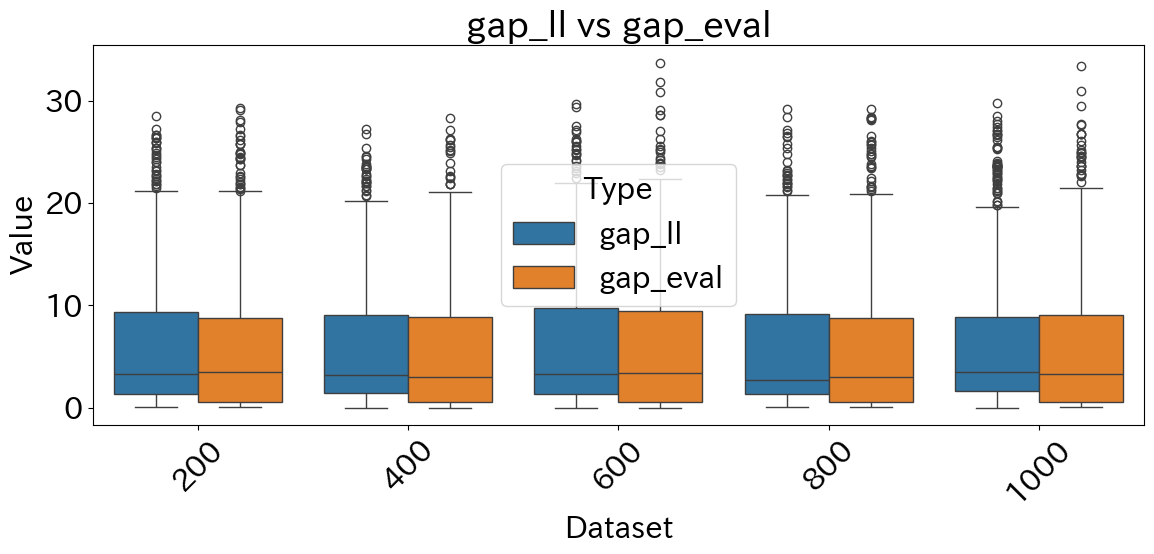

In [ ]:
plot_data = []

for label, ll_vals, ev_vals in zip(dataset_list, clean_gap_ll, clean_gap_eval):
    # ll_vals, ev_vals shape = (num_cases, 3)

    for vec in ll_vals:
        for d in range(len(vec)):  # 3次元分ループ
            plot_data.append({"Dataset": label, "Value": vec[d], "Type": "gap_ll", "Dim": d})

    for vec in ev_vals:
        for d in range(len(vec)):
            plot_data.append({"Dataset": label, "Value": vec[d], "Type": "gap_eval", "Dim": d})

df = pd.DataFrame(plot_data)

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Dataset", y="Value", hue="Type")
plt.title("gap_ll vs gap_eval")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


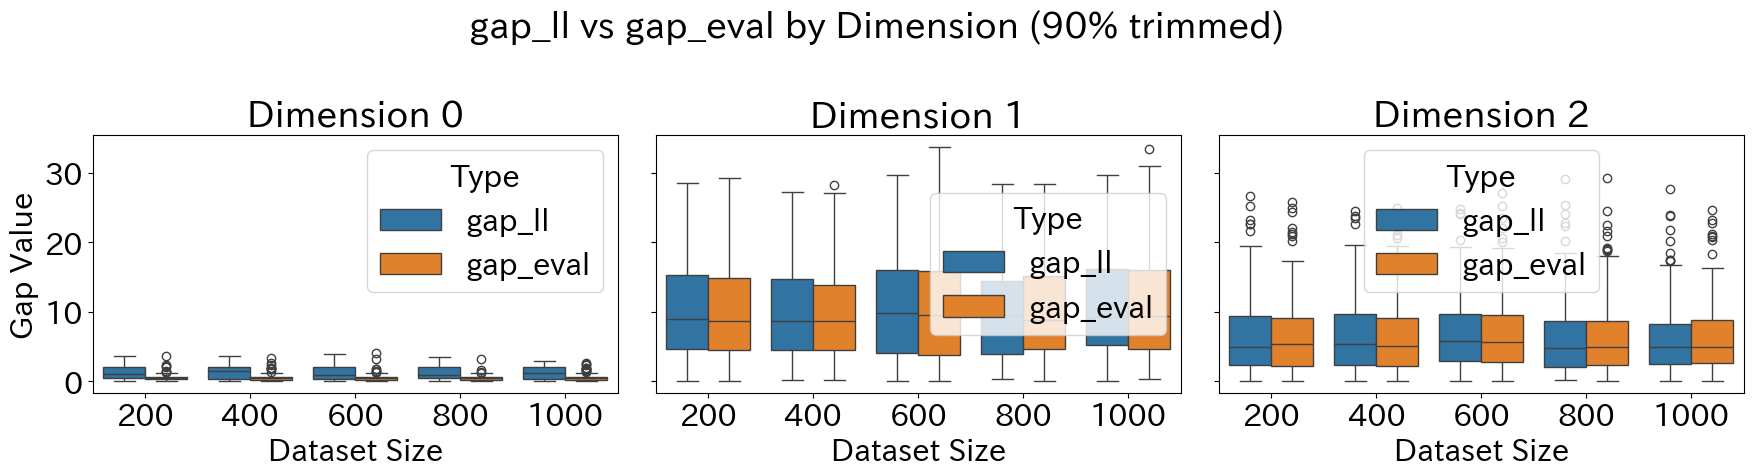

In [ ]:


plot_data = []

# データ展開：各次元を独立行として整形
for label, ll_vals, ev_vals in zip(dataset_list, clean_gap_ll, clean_gap_eval):
    for vec in ll_vals:
        for d in range(len(vec)):
            plot_data.append({"Dataset": label, "Value": vec[d], "Type": "gap_ll", "Dim": d})

    for vec in ev_vals:
        for d in range(len(vec)):
            plot_data.append({"Dataset": label, "Value": vec[d], "Type": "gap_eval", "Dim": d})

df = pd.DataFrame(plot_data)

# ---- グラフ描画 ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for d in range(3):
    sns.boxplot(
        data=df[df["Dim"] == d],
        x="Dataset",
        y="Value",
        hue="Type",
        ax=axes[d]
    )
    axes[d].set_title(f"Dimension {d}")
    axes[d].set_xlabel("Dataset Size")
    axes[d].set_ylabel("Gap Value")

plt.suptitle("gap_ll vs gap_eval by Dimension (90% trimmed)")
plt.tight_layout()
plt.show()
